# Predicting Spatial Variability from Component Contributions
This notebook builds upon the multi-source spatial variability framework to **predict yield surfaces from underlying spatial components** (trend, stripes, soil) and compare predictions to actual simulated yields.

In [1]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
np.random.seed(42)

# Synthetic field parameters
nr, nc = 40, 40
x, y = np.meshgrid(np.arange(nc), np.arange(nr))

# Generate components
y_trend = 0.6*(x/x.max()) + 0.4*(y/y.max())
stripe_w = 4
y_stripe = ((x // stripe_w) % 2).astype(float) - 0.5
def gaussian_blob(cx, cy, sx, sy, amp):
    return amp*np.exp(-(((x-cx)**2)/(2*sx**2)+((y-cy)**2)/(2*sy**2)))
y_soil = sum(gaussian_blob(np.random.randint(0,nc), np.random.randint(0,nr),
                           np.random.uniform(2,6), np.random.uniform(2,6),
                           np.random.uniform(-1,1)) for _ in range(8))
y_noise = np.random.normal(0,0.05,(nr,nc))

# True yield surface
yield_field = 2.0 + 0.9*y_trend + 0.6*y_stripe + 0.8*y_soil + y_noise


## Fit Regression Model from Components

In [2]:
X = np.column_stack([y_trend.ravel(), y_stripe.ravel(), y_soil.ravel()])
y = yield_field.ravel()

reg = LinearRegression().fit(X, y)
coeffs = np.round(reg.coef_,3)
intercept = np.round(reg.intercept_,3)
print('Coefficients (Trend, Stripe, Soil):', coeffs)
print('Intercept:', intercept)

y_pred = reg.predict(X).reshape(nr, nc)
residuals = yield_field - y_pred

Coefficients (Trend, Stripe, Soil): [0.891 0.597 0.813]
Intercept: 2.006


## Evaluate Model Fit

In [3]:
r2 = r2_score(y, y_pred.ravel())
mae = mean_absolute_error(y, y_pred.ravel())
rmse = mean_squared_error(y, y_pred.ravel(), squared=False)
print(f'R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}')

R²=0.987, MAE=0.040, RMSE=0.049


## Predicted vs. Actual Yield Fields

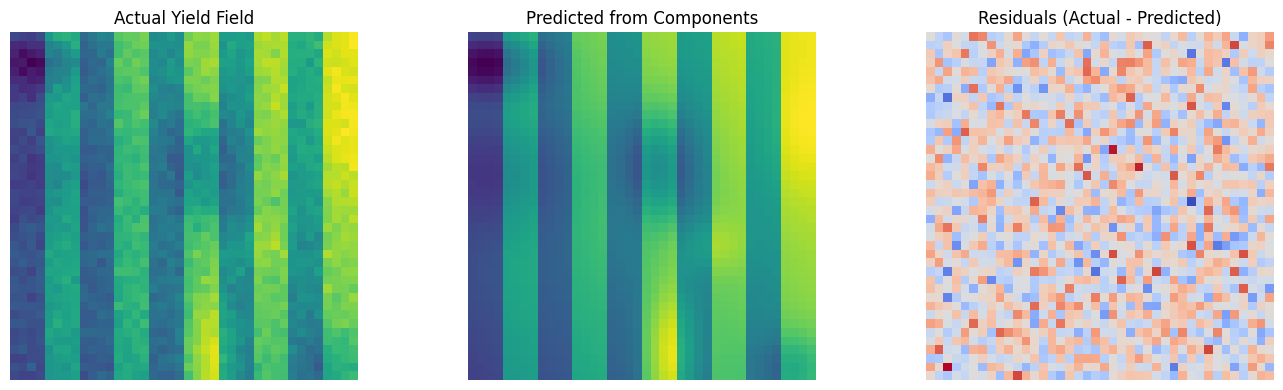

In [4]:
fig, axs = plt.subplots(1,3,figsize=(14,4))
axs[0].imshow(yield_field, origin='lower', cmap='viridis'); axs[0].set_title('Actual Yield Field')
axs[1].imshow(y_pred, origin='lower', cmap='viridis'); axs[1].set_title('Predicted from Components')
axs[2].imshow(residuals, origin='lower', cmap='coolwarm'); axs[2].set_title('Residuals (Actual - Predicted)')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

## Spatial Autocorrelation of Residuals (Moran’s I)

In [5]:
coords = np.column_stack([x.ravel(), y.ravel()])
dist = cdist(coords, coords)
W = np.exp(-dist**2/(2*3.0**2)); np.fill_diagonal(W, 0)

def morans_I(y, W):
    z = y - y.mean()
    num = np.sum(W * np.outer(z, z))
    denom = np.sum(W) * np.sum(z**2)
    return (len(y)/np.sum(W)) * (num / np.sum(z**2))

I_resid = morans_I(residuals.ravel(), W)
print(f"Moran's I (residuals): {I_resid:.3f}")

Moran's I (residuals): -0.002


## Visualization Panel: Components, Prediction, and Residuals

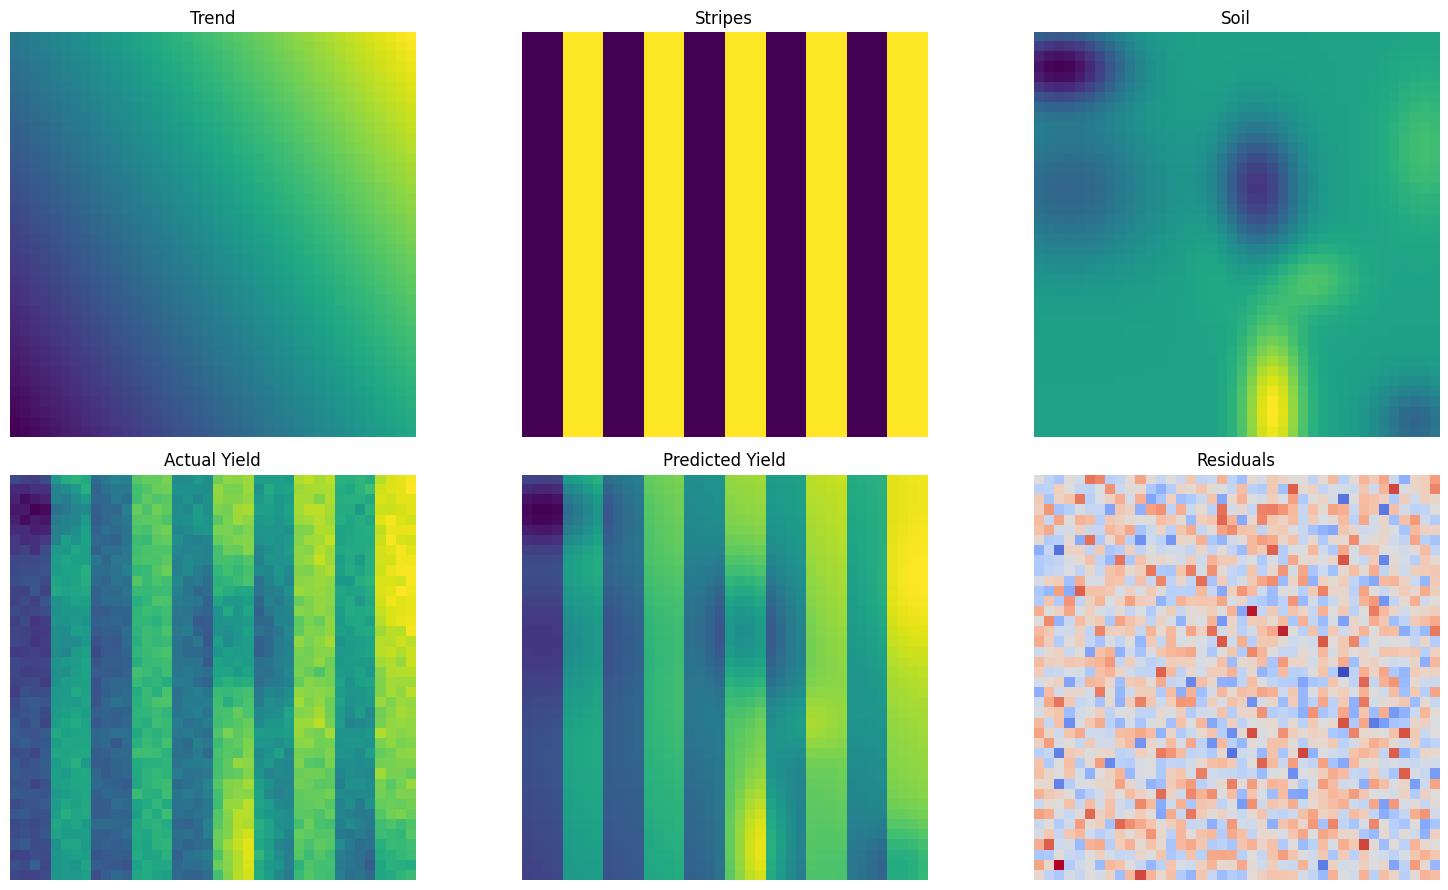

,Component,Coefficient
0,Trend,0.891
1,Stripe,0.597
2,Soil,0.813


In [6]:
fig, axs = plt.subplots(2,3,figsize=(16,9))
ims = [y_trend, y_stripe, y_soil, yield_field, y_pred, residuals]
titles = ['Trend','Stripes','Soil','Actual Yield','Predicted Yield','Residuals']
for ax,im,title in zip(axs.ravel(), ims, titles):
    ax.imshow(im, origin='lower', cmap='viridis' if 'Residual' not in title else 'coolwarm')
    ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

pd.DataFrame({'Component':['Trend','Stripe','Soil'],'Coefficient':coeffs})

## Interpretation
- The coefficients should approximate the true generative values (≈ 0.9, 0.6, 0.8).
- Residuals represent unexplained variability (e.g., random noise or nonlinear effects).
- Moran’s I quantifies whether residuals remain spatially structured.